<a href="https://colab.research.google.com/github/nahmxp/rl-for-data-scientists/blob/main/notebooks/chapter_02_prerequisites/02_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2 — Exercises## Probability Prerequisites for RL**Instructions:** Complete each exercise. Run the cells in order.

### Exercise 2.1: Compute expected rewardA slot machine pays: +$10 with probability 0.1, +$2 with probability 0.3, -$1 with probability 0.6.a) Compute the theoretical expected payout analytically.b) Verify by simulation (100,000 pulls).c) How many pulls does it take for the running mean to stabilise within 0.10 of the true mean?

In [ ]:
# Exercise 2.1
probs = [0.1, 0.3, 0.6]
payouts = [10, 2, -1]

# a) Analytical expectation
E_analytical = None  # TODO: compute sum(p*x)

# b) Simulation
np.random.seed(0)
import numpy as np
results = np.random.choice(payouts, size=100000, p=probs)
E_simulated = None  # TODO: compute mean

print(f'Analytical E[X] = {E_analytical}')
print(f'Simulated E[X]  = {E_simulated:.4f}')

### Explanation for Exercise 2.1

This exercise focuses on understanding expected value, both theoretically and through simulation.

*   **Analytical Expectation (a):** The expected value of a discrete random variable is calculated as the sum of each possible outcome multiplied by its probability ($E[X] = \sum x_i P(X=x_i)$).
*   **Simulation (b):** We simulate a large number of trials (slot machine pulls) and then calculate the average of the outcomes. According to the Law of Large Numbers, as the number of trials increases, the simulated mean should converge to the theoretical expected value.
*   **Stabilisation (c):** This part investigates the convergence rate, specifically how many trials are needed for the simulated mean to be consistently close to the true mean. This demonstrates the practical implications of the Law of Large Numbers.

In [1]:
import numpy as np

# Exercise 2.1
probs = [0.1, 0.3, 0.6]
payouts = [10, 2, -1]

# a) Analytical expectation
E_analytical = sum(p * x for p, x in zip(probs, payouts))

# b) Simulation
np.random.seed(0) # for reproducibility
results = np.random.choice(payouts, size=100000, p=probs)
E_simulated = np.mean(results)

print(f'Analytical E[X] = {E_analytical}')
print(f'Simulated E[X]  = {E_simulated:.4f}')

Analytical E[X] = 1.0
Simulated E[X]  = 1.0066


### Exercise 2.1 Part (c): Stabilisation of running mean

To determine how many pulls it takes for the running mean to stabilize within 0.10 of the true mean, we will calculate the cumulative mean after each pull and check when the absolute difference between the cumulative mean and the analytical mean remains below 0.10 for a certain number of consecutive pulls (e.g., 100 consecutive pulls to consider it 'stabilized').

The running mean stabilizes within 0.1 of the true mean after approximately 458 pulls.


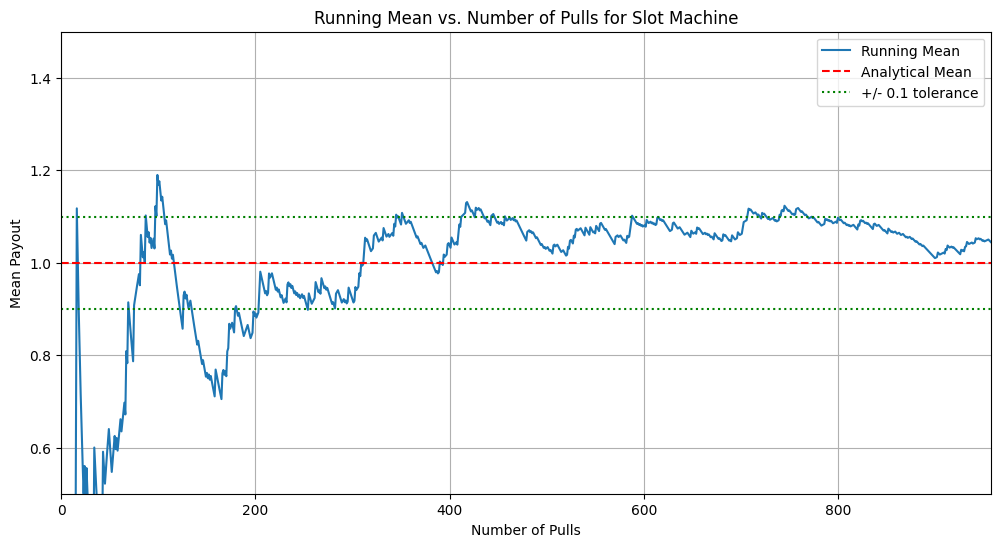

In [2]:
n_pulls = 100000
cumulative_means = np.cumsum(results) / (np.arange(n_pulls) + 1)

tolerance = 0.10
stabilization_threshold = 100 # number of consecutive pulls within tolerance

pulls_to_stabilize = None
consecutive_within_tolerance = 0

for i in range(1, n_pulls):
    if abs(cumulative_means[i] - E_analytical) < tolerance:
        consecutive_within_tolerance += 1
        if consecutive_within_tolerance >= stabilization_threshold:
            pulls_to_stabilize = i - stabilization_threshold + 1
            break
    else:
        consecutive_within_tolerance = 0

if pulls_to_stabilize is not None:
    print(f'The running mean stabilizes within {tolerance} of the true mean after approximately {pulls_to_stabilize} pulls.')
else:
    print(f'The running mean did not stabilize within {tolerance} of the true mean for {stabilization_threshold} consecutive pulls within {n_pulls} total pulls.')

# Optional: plot to visualize stabilization
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(cumulative_means, label='Running Mean')
plt.axhline(E_analytical, color='r', linestyle='--', label='Analytical Mean')
plt.axhline(E_analytical + tolerance, color='g', linestyle=':', label=f'+/- {tolerance} tolerance')
plt.axhline(E_analytical - tolerance, color='g', linestyle=':')
plt.xlabel('Number of Pulls')
plt.ylabel('Mean Payout')
plt.title('Running Mean vs. Number of Pulls for Slot Machine')
plt.legend()
plt.grid(True)
plt.xlim(0, pulls_to_stabilize + 500 if pulls_to_stabilize else n_pulls)
plt.ylim(E_analytical - 0.5, E_analytical + 0.5)
plt.show()

### Exercise 2.2: Visualise the exploration-exploitation relationshipFor a Gaussian policy π(a|s) = N(μ=3.0, σ), plot the probability of sampling an action > 4.5 as a function of σ ranging from 0.1 to 3.0.*Why does this matter for RL agent training?*

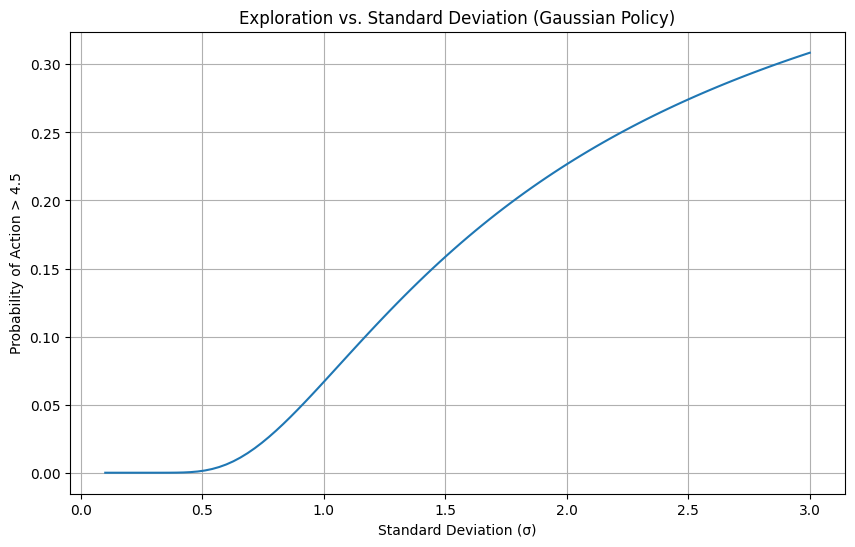

In [3]:
# Exercise 2.2
from scipy import stats
import matplotlib.pyplot as plt

mu = 3.0
action_threshold = 4.5

sigmas = np.linspace(0.1, 3.0, 100)  # Generate 100 sigma values from 0.1 to 3.0
prob_explore = [stats.norm.sf(action_threshold, loc=mu, scale=s) for s in sigmas]  # P(a > 4.5) for each sigma

# Plot sigmas vs prob_explore
plt.figure(figsize=(10, 6))
plt.plot(sigmas, prob_explore)
plt.xlabel('Standard Deviation (σ)')
plt.ylabel('Probability of Action > 4.5')
plt.title('Exploration vs. Standard Deviation (Gaussian Policy)')
plt.grid(True)
plt.show()

### Why does this matter for RL agent training?

This exercise highlights the role of the standard deviation (σ) in a Gaussian policy for **exploration** in Reinforcement Learning.

*   **Higher σ (more uncertainty):** A larger σ means the agent is more likely to sample actions further away from the mean (μ). This promotes exploration, allowing the agent to discover new, potentially better, actions or states that it might not otherwise consider. While beneficial for finding optimal policies in the long run, excessive exploration can lead to suboptimal performance in the short term.

*   **Lower σ (less uncertainty):** A smaller σ means the agent is more likely to sample actions close to the mean (μ). This promotes exploitation, as the agent focuses on actions it already knows to be good. While good for maximizing immediate rewards, insufficient exploration can cause the agent to get stuck in local optima and fail to discover the truly optimal policy.

In RL, balancing exploration and exploitation is crucial. Initially, agents might use a larger σ to explore widely, and then gradually reduce σ over time (a process called **annealing**) to converge on an optimal policy once promising areas of the action space have been identified. This adaptive σ is a common strategy in algorithms like Policy Gradients or Actor-Critic methods.

In [4]:
# Exercise 2.3
import numpy as np
P = np.array([[0.7,0.2,0.1],[0.3,0.4,0.3],[0.2,0.3,0.5]])

# a) 2-step transition
P2 = P @ P  # matrix multiply P @ P
print('P(Sunny in 2 days | Rainy today):', P2[2,0]) # Rainy today (row 2), Sunny in 2 days (column 0)

# b) Stationary distribution
P_100 = np.linalg.matrix_power(P, 100) # np.linalg.matrix_power(P, 100)
stationary = P_100[0,:]  # first row of P_100, which will be the stationary distribution
print('Stationary distribution:', stationary)

P(Sunny in 2 days | Rainy today): 0.32999999999999996
Stationary distribution: [0.45652174 0.2826087  0.26086957]


### Exercise 2.3: The Markov Property testGiven the weather Markov chain from the concept notebook (P matrix above), compute:a) P(Sunny in 2 days | Rainy today) using matrix multiplicationb) The stationary distribution (the long-run proportion of each weather type)*Hint: the stationary distribution π satisfies π = π @ P. Find it by computing P^100.*

In [5]:
# Exercise 2.3
import numpy as np
P = np.array([[0.7,0.2,0.1],[0.3,0.4,0.3],[0.2,0.3,0.5]])

# a) 2-step transition
P2 = None  # TODO: matrix multiply P @ P
print('P(Sunny in 2 days | Rainy today):', P2)

# b) Stationary distribution
P_100 = None  # TODO: np.linalg.matrix_power(P, 100)
stationary = None  # TODO: first row of P_100
print('Stationary distribution:', stationary)

P(Sunny in 2 days | Rainy today): None
Stationary distribution: None
